In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# SIMPLE LINEAR REGRESSION

In [ ]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head(4)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255


In [ ]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


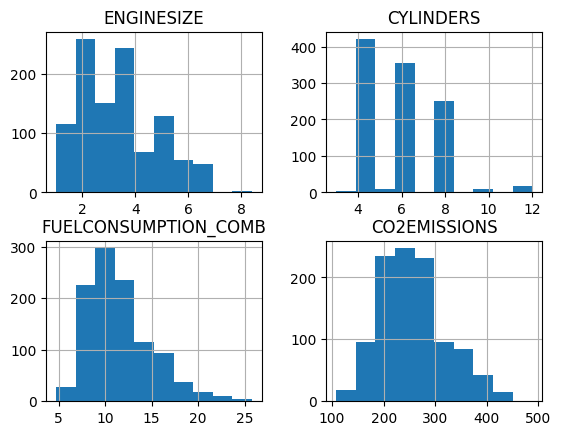

In [ ]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.hist()
plt.show()

Text(0, 0.5, 'Emission')

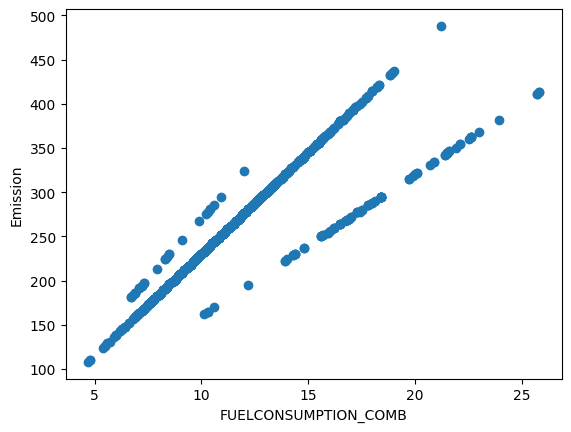

In [ ]:
plt.scatter(df["FUELCONSUMPTION_COMB"], df["CO2EMISSIONS"])
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")

Text(0, 0.5, 'Emission')

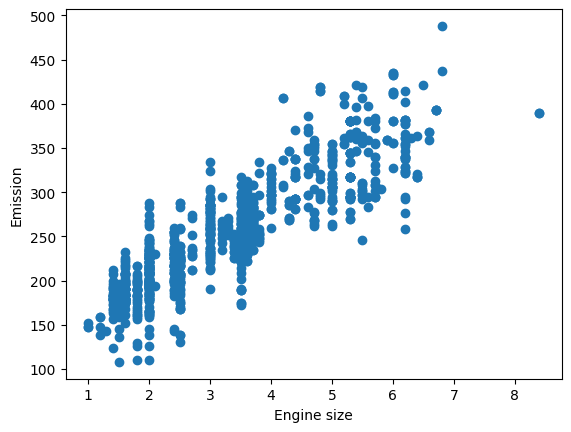

In [ ]:
plt.scatter(df["ENGINESIZE"], df["CO2EMISSIONS"])
plt.xlabel("Engine size")
plt.ylabel("Emission")


Text(0, 0.5, 'Emission')

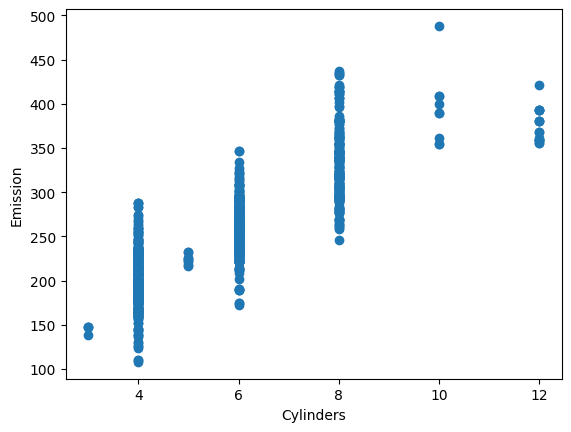

In [ ]:
plt.scatter(df["CYLINDERS"], df["CO2EMISSIONS"])
plt.xlabel("Cylinders")
plt.ylabel("Emission")

In [ ]:
X = df["FUELCONSUMPTION_COMB"].to_numpy()
y = df["CO2EMISSIONS"].to_numpy()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [ ]:
type(X_train), np.shape(X_train), np.shape(X_test), np.shape(y_train), np.shape(y_test)

(numpy.ndarray, (853,), (214,), (853,), (214,))

In [ ]:
from sklearn import linear_model
model = linear_model.LinearRegression()
model.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

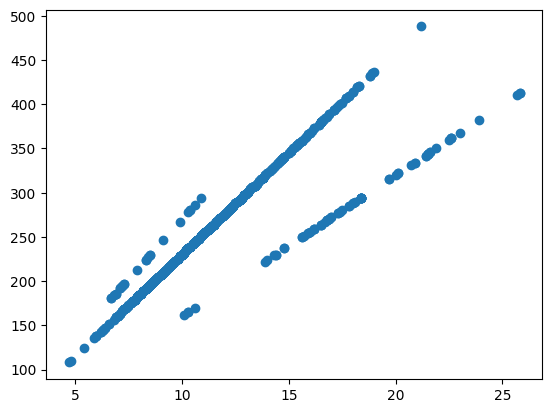

In [ ]:
plt.scatter(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test.reshape(-1, 1))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mae: {mae:.2f}, mse: {mse:.2f}, r2 score is {r2:.2f}")

mae: 19.17, mse: 736.54, r2 score is 0.80


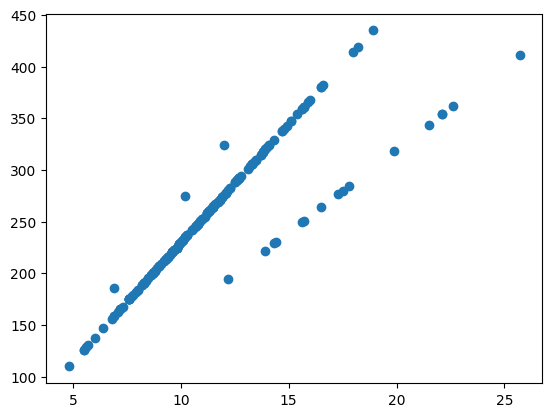

In [ ]:
plt.scatter(X_test, y_test)

In [ ]:
# MULTIPLE LINEAR REGRESSION

In [ ]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [ ]:
df = pd.read_csv(url)
df.head(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)

In [ ]:
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [ ]:
# 'ENGINESIZE' and 'CYLINDERS' are highly correlated, but 'ENGINESIZE' is more correlated with the target, so we can drop 'CYLINDERS'.
# Similarly, each of the four fuel economy variables is highly correlated with each other. Since FUELCONSUMPTION_COMB_MPG is the most correlated with the target, you can drop the others.

In [ ]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)

Text(0, 0.5, 'Emission')

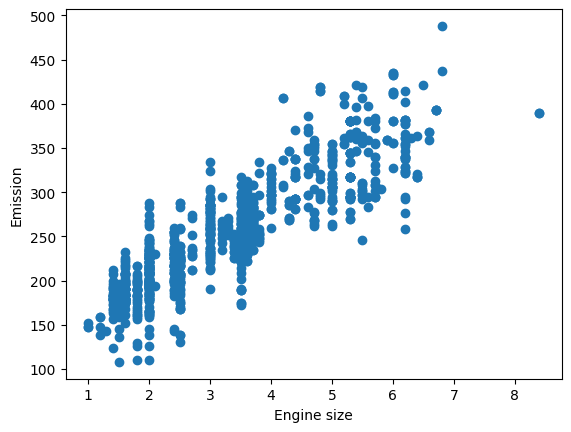

In [ ]:
plt.scatter(df["ENGINESIZE"], df["CO2EMISSIONS"])
plt.xlabel("Engine size")
plt.ylabel("Emission")

Text(0, 0.5, 'Emission')

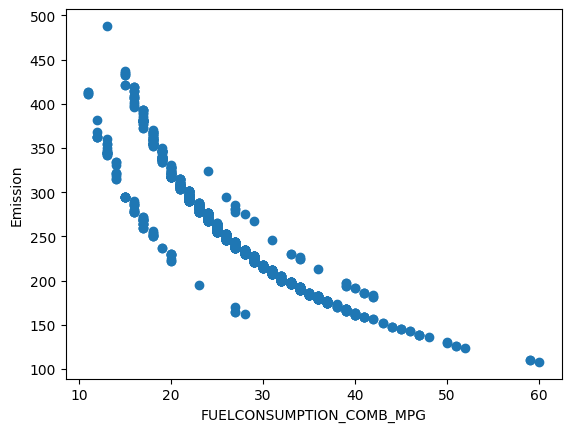

In [ ]:
plt.scatter(df["FUELCONSUMPTION_COMB_MPG"], df["CO2EMISSIONS"])
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")

In [ ]:
df.head(3)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136


In [ ]:
X = df.iloc[:, 0:2].to_numpy()
y = df.iloc[:, 2].to_numpy()

In [ ]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=12)

In [ ]:
from sklearn import linear_model
model = linear_model.LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mae: {mae:.2f}, mse: {mse:.2f}, r2 score is {r2:.2f}")

mae: 13.89, mse: 401.40, r2 score is 0.90


In [ ]:
# POLYNOMIAL REGRESSION

In [2]:
import numpy as np
from sklearn import linear_model

In [3]:
X = np.array([[1],[2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([6, 9, 14, 21, 30, 41, 54, 69, 86, 105])

In [4]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [5]:
model = linear_model.LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [9]:
print(model.predict(poly.transform([[20]])))

[405.]


In [ ]:
# Non-linear regression is simply Decision tree, random forest, xg-boost, neural networks ....

In [ ]:
# LOGISTIC REGRESSION

In [11]:
import numpy as np
import pandas as pd

In [10]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"

In [12]:
df = pd.read_csv(url)

In [23]:
from sklearn.preprocessing import StandardScaler
X = df.loc[:, ['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']]
X_norm = StandardScaler().fit(X).transform(X)
y = df["churn"]

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=99)

In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_pred = model.predict(X_test)

In [33]:
print(y_test[:5], y_pred[:5])

135    0.0
127    1.0
191    0.0
66     0.0
119    0.0
Name: churn, dtype: float64 [0. 0. 1. 0. 0.]


In [29]:
y_pred_prob = model.predict_proba(X_test)

In [32]:
print(y_pred_prob[:5])

[[0.98785055 0.01214945]
 [0.72393058 0.27606942]
 [0.48198244 0.51801756]
 [0.9750351  0.0249649 ]
 [0.87621841 0.12378159]]


In [35]:
from sklearn.metrics import log_loss
log_loss(y_test, y_pred)

13.216006242676288